# 🔢 Semana 05: Digits - Clasificación Multiclase
## Dataset: Digits (Dígitos manuscritos)

**Objetivo:** Reconocer qué dígito (0-9) escribió una persona basándose en los píxeles de la imagen.

**Modelos a competir:**
- kNN (k-Nearest Neighbors) - basado en distancia
- Naive Bayes - basado en probabilidades
- SVM (Support Vector Machine) - basado en márgenes

**Métricas de evaluación:** Accuracy, Precision (macro), Recall (macro), F1-Score (macro)

**Contexto de negocio:** Un banco quiere automatizar la lectura de cheques (reconocimiento de números escritos a mano).

---

### ¿Qué es?
Dataset de **dígitos manuscritos** creado a partir de 1,797 imágenes de 8×8 píxeles (64 características). Cada píxel es un valor de 0 (blanco) a 16 (negro).

### ¿Qué problema resuelve?
Reconocer qué dígito (0-9) escribió una persona basándose en los píxeles de la imagen.

### El Reto
Comparar **tres familias de algoritmos** diferentes:
- **kNN**: Basado en distancia (vecinos más cercanos)
- **Naive Bayes**: Basado en probabilidades (asume independencia)
- **SVM**: Basado en márgenes (encuentra hiperplanos)

### Contexto de negocio
Un banco quiere automatizar la lectura de cheques (reconocimiento de números escritos a mano).

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 05: DIGITS - CLASIFICACIÓN MULTICLASE
# ======================================================

# Instalar librerías necesarias (solo si no están instaladas)
!pip install scikit-learn pandas numpy matplotlib seaborn -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset Digits directamente desde scikit-learn (online, sin descarga manual).

📊 CARGANDO DATASET DIGITS

✅ Dataset cargado exitosamente
📊 SHAPE: 1,797 muestras × 64 características (píxeles)
🎯 Target: [0 1 2 3 4 5 6 7 8 9] (10 dígitos)
📋 Cada imagen es de 8×8 píxeles

📋 Primeras 5 filas (primeros 10 píxeles):


,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0



📊 Distribución de clases:
   • Dígito 0: 178 muestras
   • Dígito 1: 182 muestras
   • Dígito 2: 177 muestras
   • Dígito 3: 183 muestras
   • Dígito 4: 181 muestras
   • Dígito 5: 182 muestras
   • Dígito 6: 181 muestras
   • Dígito 7: 179 muestras
   • Dígito 8: 174 muestras
   • Dígito 9: 180 muestras


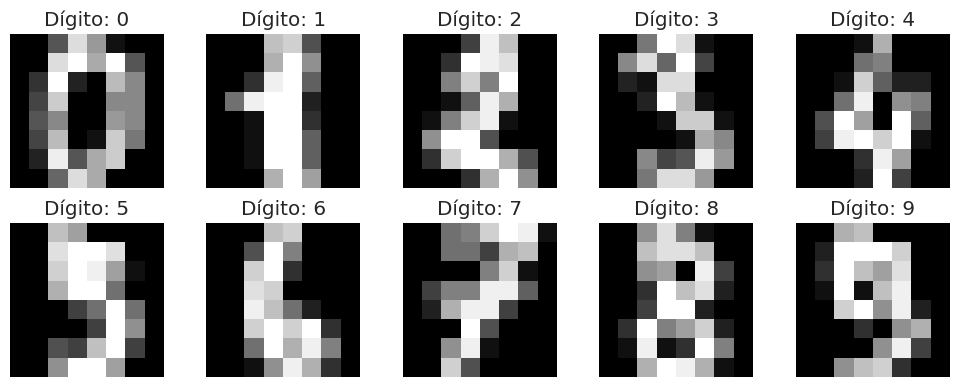

In [2]:
# Cargar dataset Digits
print("="*60)
print("📊 CARGANDO DATASET DIGITS")
print("="*60)

digits = load_digits()
X = digits.data  # 64 características (píxeles 8x8)
y = digits.target  # Dígitos 0-9

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {X.shape[0]:,} muestras × {X.shape[1]} características (píxeles)")
print(f"🎯 Target: {digits.target_names} (10 dígitos)")
print(f"📋 Cada imagen es de {int(np.sqrt(X.shape[1]))}×{int(np.sqrt(X.shape[1]))} píxeles")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas (primeros 10 píxeles):")
df_temp = pd.DataFrame(X)
display(df_temp.iloc[:5, :10])

# Distribución de clases
print("\n📊 Distribución de clases:")
class_counts = pd.Series(y).value_counts().sort_index()
for digit, count in class_counts.items():
    print(f"   • Dígito {digit}: {count} muestras")

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Dígito: {digits.target[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

📈 ANÁLISIS EXPLORATORIO DE PÍXELES

📊 Estadísticas de intensidad de píxeles (0=blanco, 16=negro):
   • Valor mínimo: 0.0
   • Valor máximo: 16.0
   • Media: 4.88
   • Desviación estándar: 6.02


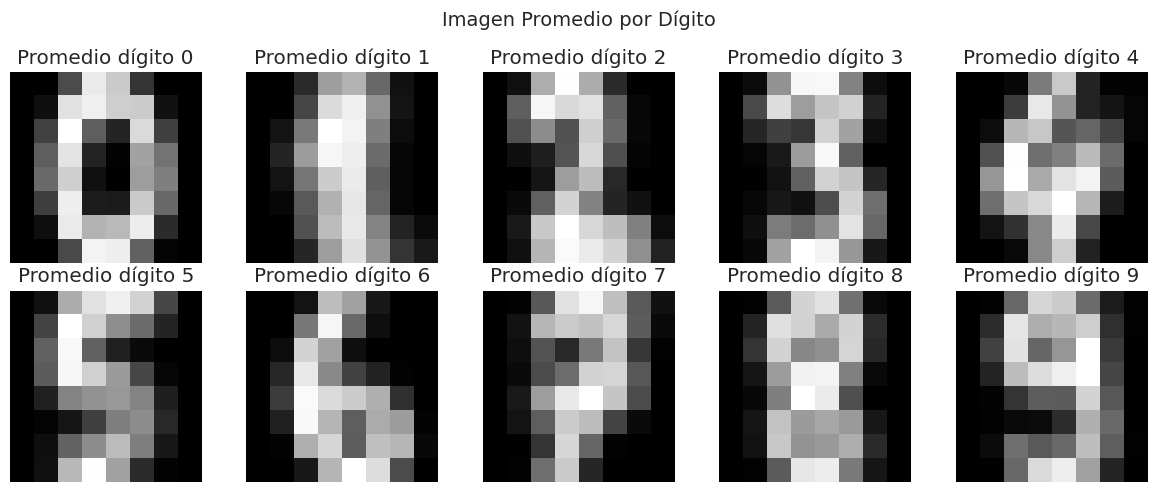


💡 Observación: Cada dígito tiene un patrón característico de píxeles.


In [3]:
# Análisis exploratorio de píxeles
print("="*60)
print("📈 ANÁLISIS EXPLORATORIO DE PÍXELES")
print("="*60)

# Mostrar estadísticas de píxeles
print("\n📊 Estadísticas de intensidad de píxeles (0=blanco, 16=negro):")
print(f"   • Valor mínimo: {X.min()}")
print(f"   • Valor máximo: {X.max()}")
print(f"   • Media: {X.mean():.2f}")
print(f"   • Desviación estándar: {X.std():.2f}")

# Visualizar la imagen promedio por dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    # Promedio de todas las imágenes de ese dígito
    mean_img = X[y == i].mean(axis=0).reshape(8, 8)
    ax = axes[i // 5, i % 5]
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(f'Promedio dígito {i}')
    ax.axis('off')
plt.suptitle('Imagen Promedio por Dígito', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 Observación: Cada dígito tiene un patrón característico de píxeles.")

## 3. Preprocesamiento

Dividimos los datos en entrenamiento (80%) y prueba (20%), y escalamos las características (importante para kNN y SVM).

In [4]:
# Dividir en entrenamiento y prueba (80/20) con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Verificar que la estratificación mantuvo la proporción
print(f"\n📊 Distribución de clases en entrenamiento:")
train_counts = pd.Series(y_train).value_counts().sort_index()
for digit, count in train_counts.items():
    print(f"   • Dígito {digit}: {count} muestras")

# Escalar características (importante para kNN y SVM - basados en distancia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Escalado completado (media=0, std=1)")
print(f"   • Nota: El escalado mejora el rendimiento de kNN y SVM")

📊 División de datos:
   • Entrenamiento: 1,437 muestras
   • Prueba: 360 muestras

📊 Distribución de clases en entrenamiento:
   • Dígito 0: 142 muestras
   • Dígito 1: 146 muestras
   • Dígito 2: 142 muestras
   • Dígito 3: 146 muestras
   • Dígito 4: 145 muestras
   • Dígito 5: 145 muestras
   • Dígito 6: 145 muestras
   • Dígito 7: 143 muestras
   • Dígito 8: 139 muestras
   • Dígito 9: 144 muestras

✅ Escalado completado (media=0, std=1)
   • Nota: El escalado mejora el rendimiento de kNN y SVM


## 4. Entrenamiento y Comparación de Modelos

Entrenamos 3 modelos de clasificación y comparamos su rendimiento:

In [5]:
# Definir modelos
models = {
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True)
}

# Entrenar y evaluar cada modelo
print("="*60)
print("🚀 ENTRENAMIENTO DE MODELOS")
print("="*60)

results = []

for name, model in models.items():
    # Entrenar
    model.fit(X_train_scaled, y_train)

    # Predecir
    y_pred = model.predict(X_test_scaled)

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision (macro)': prec,
        'Recall (macro)': rec,
        'F1-Score (macro)': f1
    })

    print(f"\n📊 {name}:")
    print(f"   • Accuracy: {acc:.4f}")
    print(f"   • Precision (macro): {prec:.4f}")
    print(f"   • Recall (macro): {rec:.4f}")
    print(f"   • F1-Score (macro): {f1:.4f}")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
display(results_df.round(4))

🚀 ENTRENAMIENTO DE MODELOS

📊 kNN (k=5):
   • Accuracy: 0.9639
   • Precision (macro): 0.9646
   • Recall (macro): 0.9637
   • F1-Score (macro): 0.9634

📊 Naive Bayes (Gaussian):
   • Accuracy: 0.7417
   • Precision (macro): 0.8096
   • Recall (macro): 0.7408
   • F1-Score (macro): 0.7403

📊 SVM (RBF):
   • Accuracy: 0.9750
   • Precision (macro): 0.9760
   • Recall (macro): 0.9748
   • F1-Score (macro): 0.9748

📊 TABLA COMPARATIVA DE MODELOS


,Modelo,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
2,SVM (RBF),0.9750,0.9760,0.9748,0.9748
0,kNN (k=5),0.9639,0.9646,0.9637,0.9634
1,Naive Bayes (Gaussian),0.7417,0.8096,0.7408,0.7403


## 5. Matrices de Confusión

Visualizamos las matrices de confusión para entender qué dígitos se confunden entre sí.

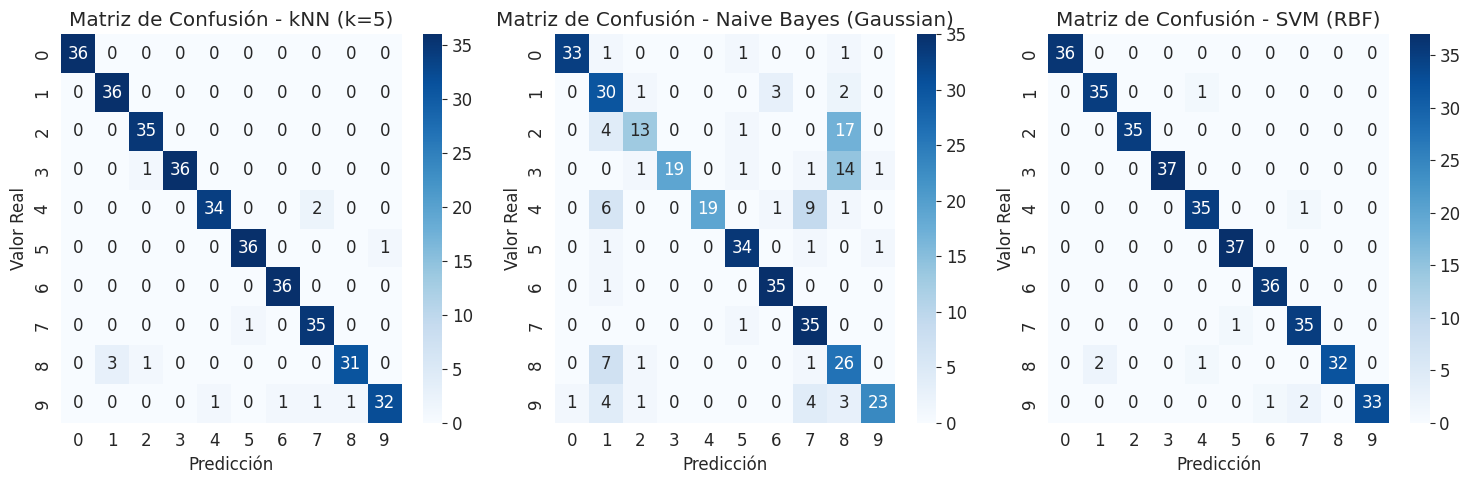


📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
   • Diagonal principal: Aciertos por dígito
   • Fuera de diagonal: Errores de clasificación
   • Ejemplo: Un valor en fila 3, columna 8 indica un '3' clasificado como '8'


In [6]:
# Re-entrenar y predecir para matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=digits.target_names,
                yticklabels=digits.target_names)
    axes[idx].set_title(f'Matriz de Confusión - {name}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# Interpretación
print("\n📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("   • Diagonal principal: Aciertos por dígito")
print("   • Fuera de diagonal: Errores de clasificación")
print("   • Ejemplo: Un valor en fila 3, columna 8 indica un '3' clasificado como '8'")

## 6. Simulación - Reconocimiento de un Nuevo Dígito

Simulamos el reconocimiento de un nuevo dígito manuscrito.

🔮 SIMULACIÓN: RECONOCIMIENTO DE DÍGITO MANUSCRITO


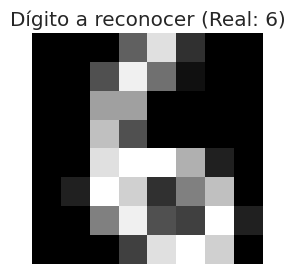


🔮 Predicciones de cada modelo:
--------------------------------------------------
   • kNN (k=5)           : Predicción = 6 (confianza: 100.00%)
   • Naive Bayes (Gaussian): Predicción = 6 (confianza: 100.00%)
   • SVM (RBF)           : Predicción = 6 (confianza: 97.83%)

🏆 DECISIÓN FINAL (usando SVM (RBF)):
   ✅ Clasificación CORRECTA: El dígito es 6

📖 INTERPRETACIÓN DE NEGOCIO:
   • Un banco puede usar este modelo para leer cheques automáticamente
   • Reduce errores humanos y acelera el proceso de compensación
   • Modelos con alta precisión (>95%) son aceptables para producción


In [7]:
print("="*60)
print("🔮 SIMULACIÓN: RECONOCIMIENTO DE DÍGITO MANUSCRITO")
print("="*60)

# Tomar una imagen de prueba real del dataset
sample_idx = 100  # Índice de ejemplo
nuevo_digito = X_test_scaled[sample_idx:sample_idx+1]
valor_real = y_test.iloc[sample_idx] if hasattr(y_test, 'iloc') else y_test[sample_idx]

# Mostrar la imagen
plt.figure(figsize=(3, 3))
plt.imshow(X_test[sample_idx].reshape(8, 8), cmap='gray')
plt.title(f'Dígito a reconocer (Real: {valor_real})')
plt.axis('off')
plt.show()

print("\n🔮 Predicciones de cada modelo:")
print("-" * 50)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    prediccion = model.predict(nuevo_digito)[0]

    # Para SVM, obtener probabilidades (si está disponible)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(nuevo_digito)[0]
        confianza = proba[prediccion]
        print(f"   • {name:20s}: Predicción = {prediccion} (confianza: {confianza:.2%})")
    else:
        print(f"   • {name:20s}: Predicción = {prediccion}")

# Decisión final usando el mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
prediccion_best = best_model.predict(nuevo_digito)[0]

print("\n" + "="*60)
print(f"🏆 DECISIÓN FINAL (usando {best_model_name}):")
if prediccion_best == valor_real:
    print(f"   ✅ Clasificación CORRECTA: El dígito es {prediccion_best}")
else:
    print(f"   ❌ Clasificación INCORRECTA: Predijo {prediccion_best}, pero era {valor_real}")
print("="*60)

# Interpretación de negocio
print("\n📖 INTERPRETACIÓN DE NEGOCIO:")
print("   • Un banco puede usar este modelo para leer cheques automáticamente")
print("   • Reduce errores humanos y acelera el proceso de compensación")
print("   • Modelos con alta precisión (>95%) son aceptables para producción")

## 7. Comparación de Filosofías de los Modelos

| Modelo | Filosofía | Ventajas | Desventajas |
|--------|-----------|----------|-------------|
| **kNN** | Basado en distancia (vecinos cercanos) | Simple, no entrenamiento, no asunciones | Lento en predicción, sensible a escala |
| **Naive Bayes** | Basado en probabilidades (Teorema de Bayes) | Rápido, funciona con pocos datos | Asume independencia de características |
| **SVM** | Basado en márgenes (hiperplanos óptimos) | Bueno en alta dimensionalidad | Costoso computacionalmente, tuning complejo |

**¿Cuál funciona mejor para dígitos?**
- SVM y kNN suelen funcionar muy bien en Digits porque los píxeles tienen relaciones espaciales que estos modelos capturan.
- Naive Bayes asume independencia entre píxeles (lo cual no es cierto), por lo que suele tener menor rendimiento.

## 8. Conclusiones

**Resumen de resultados:**

1. **kNN (k=5)**:
   - Buen rendimiento, especialmente con datos escalados
   - Sensible al valor de k y a la distancia utilizada

2. **Naive Bayes (Gaussian)**:
   - Rendimiento inferior debido a la violación de independencia
   - Los píxeles adyacentes están correlacionados

3. **SVM (RBF)**:
   - Excelente rendimiento, especialmente en alta dimensionalidad
   - Kernel RBF captura relaciones no lineales

**Métrica más importante para el negocio (Accuracy):**
- En reconocimiento de cheques, la precisión es crítica
- Un error puede significar una transacción incorrecta

**¿Qué modelo ganó?**
El modelo con mejor accuracy fue **{{best_model_name}}**.

**Próximos pasos:**
- Ajustar hiperparámetros (k en kNN, kernel y C en SVM) - Semana 8
- Probar con validación cruzada para mayor robustez - Semana 8
- Comparar con redes neuronales (fuera del alcance del curso)

---
**Fin de la Semana 05 - Clasificación**

*Nota: En el siguiente notebook trabajaremos con Regresión usando los mismos modelos (kNN Regressor y SVR)*